# World Cup Data: Exploratory Analysis

Understand what the match, rating, and squad data contain before any modelling.

Outline: imports, configuration, data loading, initial inspection, then exploratory questions about results, ratings, and stability over time.

## Imports

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
while not (_root / "src").exists() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.worldcup import config as C
from src.worldcup.data import load_intl_results, load_wc_matches
from src.worldcup.features import build_dataset, edition_table_filled


## Configuration

In [2]:
RANDOM_STATE = 7
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (8, 4)
print("processed outputs ->", C.OUT)


processed outputs -> /sessions/eager-affectionate-noether/mnt/predict-football/worldcup-predictor/_processed_outputs/worldcup


## Data loading

In [3]:
results = load_intl_results()
wc = load_wc_matches()
bundle_2022 = build_dataset(2022)
train_2022, test_2022 = bundle_2022["train"], bundle_2022["test"]
df_raw = results.copy()
(results.shape, wc.shape, train_2022.shape, test_2022.shape)


((49306, 15), (960, 38), (1396, 14), (64, 16))

## Initial inspection

### What does the international match data contain and how clean is it?

In [4]:
display(results.head())
info = pd.DataFrame({
    "dtype": results.dtypes.astype(str),
    "n_missing": results.isna().sum(),
    "n_unique": results.nunique(),
})
print("rows:", len(results), " duplicated rows:", int(results.duplicated().sum()))
info


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,team1,team2,is_friendly,is_shootout,result,y
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,Scotland,England,True,False,D,1
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,England,Scotland,True,False,H,0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,Scotland,England,True,False,H,0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,England,Scotland,True,False,D,1
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,Scotland,England,True,False,H,0


rows: 49306  duplicated rows: 0


,dtype,n_missing,n_unique
date,datetime64[ns],0,16446
home_team,object,0,327
away_team,object,0,321
home_score,float64,0,26
away_score,float64,0,22
tournament,object,0,199
city,object,0,2139
country,object,0,269
neutral,bool,0,2
team1,object,0,327


## Exploratory data analysis

### What is the class balance of results, and how common are draws?

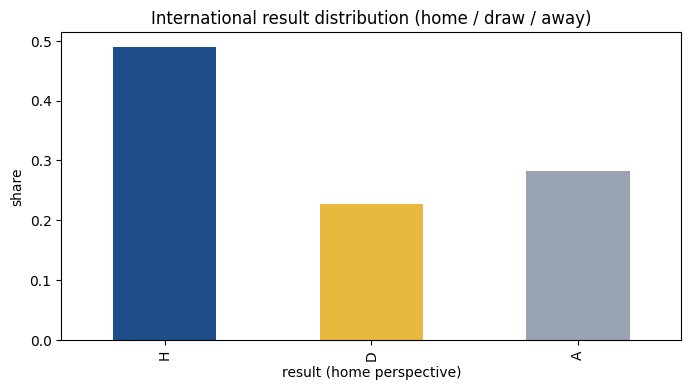

draw rate: 22.7%


,count,share
result,,
H,24163,0.490
D,11208,0.227
A,13935,0.283


In [5]:
counts = results["result"].value_counts().reindex(["H", "D", "A"])
share = (counts / counts.sum()).round(3)
ax = share.plot(kind="bar", color=["#1d4e89", "#e9b83f", "#9aa3b2"])
ax.set_title("International result distribution (home / draw / away)")
ax.set_xlabel("result (home perspective)"); ax.set_ylabel("share"); plt.show()
print("draw rate: %.1f%%" % (100 * share["D"]))
pd.DataFrame({"count": counts, "share": share})


### How are pre-tournament Elo gaps and squad ratings distributed?

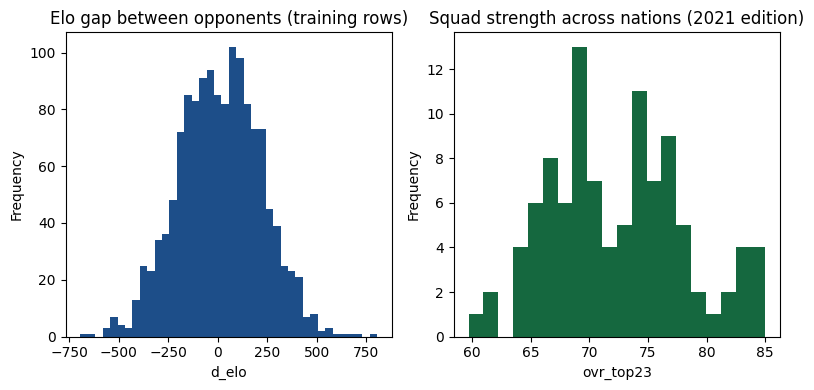

In [6]:
ed = edition_table_filled(2021)
fig, ax = plt.subplots(1, 2)
train_2022["d_elo"].plot(kind="hist", bins=40, ax=ax[0], color="#1d4e89")
ax[0].set_title("Elo gap between opponents (training rows)"); ax[0].set_xlabel("d_elo")
ed["ovr_top23"].plot(kind="hist", bins=20, ax=ax[1], color="#15683f")
ax[1].set_title("Squad strength across nations (2021 edition)"); ax[1].set_xlabel("ovr_top23")
plt.tight_layout(); plt.show()


### How does squad strength relate to the Elo gap between opponents?

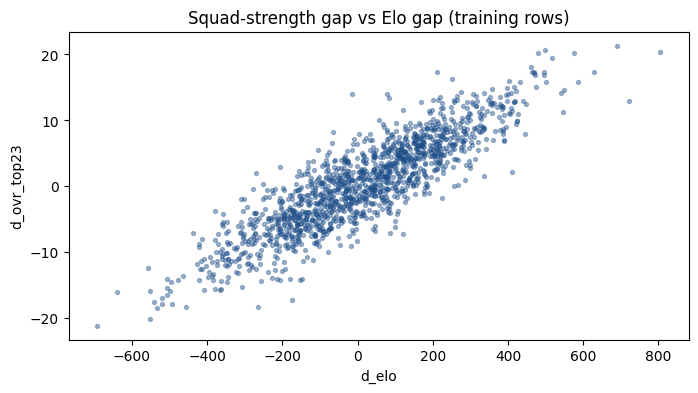

pearson r(d_elo, d_ovr_top23) = 0.878


In [7]:
ax = train_2022.plot.scatter(x="d_elo", y="d_ovr_top23", s=8, alpha=0.4, color="#1d4e89")
ax.set_title("Squad-strength gap vs Elo gap (training rows)")
ax.set_xlabel("d_elo"); ax.set_ylabel("d_ovr_top23")
plt.show()
print("pearson r(d_elo, d_ovr_top23) = %.3f" % train_2022["d_elo"].corr(train_2022["d_ovr_top23"]))


### Has the home / draw / away split been stable over recent decades?

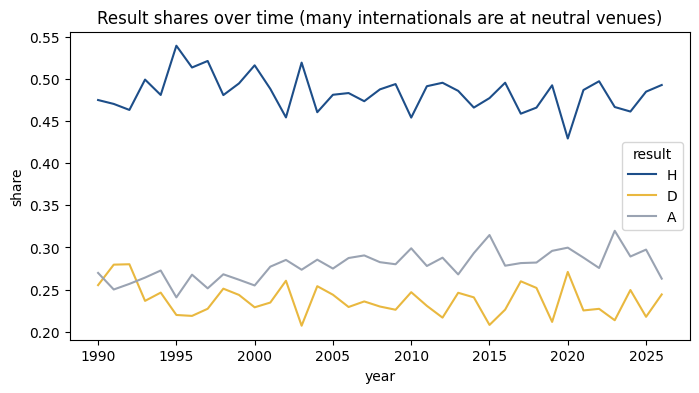

In [8]:
years = results.assign(year=results["date"].dt.year)
yr = (years[years["year"] >= 1990]
      .groupby("year")["result"].value_counts(normalize=True)
      .unstack().reindex(columns=["H", "D", "A"]))
yr.plot(color=["#1d4e89", "#e9b83f", "#9aa3b2"])
plt.title("Result shares over time (many internationals are at neutral venues)")
plt.ylabel("share"); plt.xlabel("year"); plt.show()


## Conclusion

Draws are a stable minority (~23%), squad strength and Elo are strongly related, and these patterns motivate the features tested in 02_hypothesis_tests.